In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

METRICS_DF_PATH = Path("../data/processed/metrics_result.csv")
metrics_df = pd.read_csv(METRICS_DF_PATH, index_col=0)

In [4]:
# look at the metrics
metrics_df.head()

,CV Mean F1,Test Accuracy,Precision,Recall,ROC AUC Score,F1 Score
Dummy,0.000000,0.734564,0.000000,0.000000,0.500000,0.000000
Logistic Regression,0.630326,0.741661,0.508446,0.804813,0.846364,0.623188
Random Forest,0.535590,0.779276,0.608247,0.473262,0.822274,0.532331
XG Boost,0.602521,0.755855,0.532751,0.652406,0.818405,0.586538


In [6]:
# look at XG Boost feature importance
import joblib

xg_boost_pipeline = joblib.load("../outputs/models/xg_boost.joblib")
preprocessor = xg_boost_pipeline.named_steps["preprocessor"]
xg_boost_model = xg_boost_pipeline.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()

# create importances dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xg_boost_model.feature_importances_,
}).sort_values(by="importance", ascending=False)

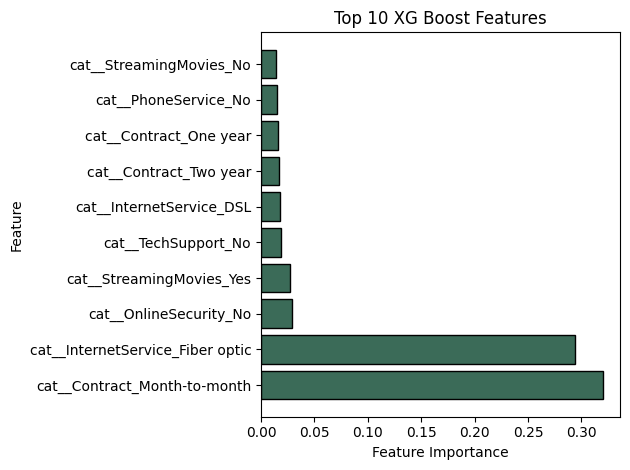

In [ ]:
top_features = importance_df.nlargest(10, "importance")

# plot it
plt.barh(top_features.feature, top_features.importance, edgecolor="black", color="#3b6b58")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 XG Boost Features")
plt.tight_layout()
plt.show()

## Machine Learning Conclusions

I trained four machine learning models, namely, a dummy classifier, logistic regression, random forest and XG Boost to predict whether a customer would churn. A few points worth mentioning:
-	The dummy classifier reached a high accuracy score (73%) only by predicting the most common class. This highlights why accuracy should not be used as the sole evaluation metric for imbalanced classification problems.
-	Logistic regression performed decently well. It achieved a precision of 50.8%, meaning that approximately half of the customers predicted to churn actually churned. Surprisingly, it achieved the highest recall, finding 80% of actual positives, the highest score across all models. By combining precision and recall, it achieved the highest F1 score (62.3%).
-	Random forest and XG Boost also performed decently, beating logistic regression on test accuracy and precision. In particular, random forest achieved the highest test accuracy (78%) and precision (61%). 
While Random Forest and XGBoost achieved higher accuracy and precision, Logistic Regression achieved the strongest balance between precision and recall, resulting in the highest F1 score.
-	All three machine learning models achieved ROC-AUC scores above 0.80, indicating a strong ability to distinguish between customers who churn and those who remain.

Looking at XG Boost feature importance, month-to-month contract was the best feature, weighting 32%. As we saw in Exploratory Data Analysis, contract was a highly effective churn predictor, which showed up in machine learning as well. Not surprisingly, other contract categories such as yearly and two-year contract also got among the top ten features.
Furthermore, support services such as online security and tech support ranked in the top five. The presence or absence of support-related services was among the most influential predictors of churn.
InternetService_Fiber optic was the second most important feature, contributing nearly as much as month-to-month contracts. This suggests that customers using fiber optic services exhibit substantially different churn behavior compared to other internet service groups.